In [2]:
from torch.utils.data import DataLoader, Subset
from gym_av_aloha.datasets.av_aloha_dataset import AVAlohaDataset
from gaze_av_aloha.policies.gaze_policy.gaze_model import GazeModel
import torch
from torch import nn, Tensor
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import imageio
import cv2
from IPython.display import Video, display
import einops
import kornia.augmentation as K
import torch.nn.utils as nn_utils
import os
from hydra import initialize_config_dir, compose
from gaze_av_aloha.configs import Config
from torchvision.transforms import Resize, Normalize
import torch.nn.functional as F


In [3]:
input_shape = (240, 320)
resize_shape=(120, 160)
# dataset = f"Jinyu220/circle_2"
# model_repo_id = f"Jinyu220/gaze_model_av_aloha_real_hang_circle_v2"
image_keys = [
    "observation.images.left_eye_cam",
]
eye_keys = [
    "left_eye",
]

In [ ]:
import torchvision.transforms as T

# Probabilities (tune these as you like)
p_blur = 1.0     # 30% chance
p_jitter = 1.0   # 50% chance

transforms = T.Compose([
    T.RandomApply(
        [T.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0))],
        p=p_blur
    ),
    T.RandomApply(
        [T.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1
        )],
        p=p_jitter
    ),
])


delta_timestamps = {
    k: [0] for k in image_keys + eye_keys
}
dataset = AVAlohaDataset(
    repo_id="iantc104/av_aloha_sim_peg_insertion_test",
    delta_timestamps=delta_timestamps,
    image_transforms=transforms
)
dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
)


avalohadataset: /home/jinyu/GitHub/gaze-av-aloha/gym_av_aloha/outputs/iantc104/av_aloha_sim_peg_insertion_test


In [5]:
batch = next(iter(dataloader))

img trnasformsimg trnasformsimg trnasforms


img trnasformsimage transforms not Noneimage transforms not Noneimage transforms not None

image transforms not Noneapplying image transforms



applying image transformsapplying image transformsapplying image transforms


img trnasforms
image transforms not None
applying image transformsimg trnasforms

image transforms not Noneimg trnasforms

image transforms not Noneapplying image transforms
applying image transforms

img trnasforms
image transforms not Noneimg trnasforms
applying image transforms

image transforms not None
img trnasformsapplying image transforms
image transforms not None

applying image transforms
img trnasforms
image transforms not None
applying image transforms
img trnasforms
image transforms not None
applying image transforms
img trnasforms
image transforms not None
applying image transforms
img trnasforms
image transforms not None
applying image transforms
img trnasforms
image transforms not None
applying image transf

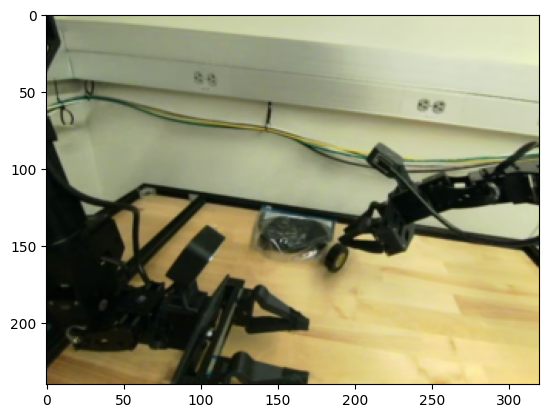

In [6]:
img = batch['observation.images.left_eye_cam'][0,0]

plt.imshow(img.permute(1, 2, 0).cpu().numpy())